# Estrategia de ofertas FDS - Pricing Justo

Notebook delgado: la logica de negocio (elegibilidad, score, cascada de
mecanica, guardrail economico, modelo economico, post-mortem) vive en
`backend/pricing/` como funciones reutilizables - este notebook solo
conecta a Snowflake, llama esas funciones y reporta resultados.

- `backend/pricing/catalog.py` - FULL_MASTER_CATALOG, VW_PRICING_DASHBOARD
- `backend/pricing/elasticity.py` - ATHENEA + fallback en cascada
- `backend/pricing/strategy.py` - toda la estrategia de ofertas
- `backend/pricing/postmortem.py` - vistas/tabla de medicion recurrente en SANDBOX

Ver el plan completo en `/home/alejomd17/.claude/plans/vamos-a-cambiar-de-glowing-plum.md`.

In [1]:
import sys
sys.path.insert(0, "..")  # para que "backend" se resuelva desde src/

import pandas as pd
import matplotlib.pyplot as plt

from backend.pricing import strategy, postmortem
from backend.pricing.snowflake_conn import get_connection

## Parametros

In [2]:
RUTA_OPORTUNIDAD = "../data/inputs/oportunidad.xlsx"
RUTA_DESCUENTOS  = "../data/inputs/Descuentos comerciales.xlsx"

# Fin de semana objetivo (ajustar cada vez que se corra para un nuevo FDS)
# CORREGIDO: la campana real fue 11-13 jul, no 10-12 jul (se habia subido
# con la fecha equivocada - ver la celda de limpieza justo antes de
# "Subir manualmente el plan real").
WEEKEND_INICIO = pd.Timestamp("2026-07-11")   # sabado
WEEKEND_FIN    = pd.Timestamp("2026-07-13")   # lunes

# Nombre de archivo unico por corrida (finde + fecha de corrida) - nunca
# sobreescribe una corrida anterior, ni de otro finde ni de este mismo.
RUTA_SALIDA = strategy.generar_ruta_salida(WEEKEND_INICIO, WEEKEND_FIN, carpeta="../data/output")
print(f"Se va a guardar en: {RUTA_SALIDA}")

Se va a guardar en: ../data/output/estrategia_fds_jul11_jul13_20260714.xlsx


## Conexion a Snowflake

SSO interactivo (`authenticator="externalbrowser"`) - al ejecutar la celda
se abre el navegador para el login de Google.

In [3]:
conn = get_connection()
cur = conn.cursor()
cur.execute("SELECT CURRENT_USER(), CURRENT_ROLE(), CURRENT_WAREHOUSE(), CURRENT_DATABASE()")
print(cur.fetchone())

Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://accounts.google.com/o/saml2/idp?idpid=C02t5osnf&SAMLRequest=lZJfb9owFMW%2FSuQ9J3YClGEREIV1sLIVNWEPffMSQ606vpmv08A%2B%2FRz%2BSN1DK%2B0hUmSf49%2B999zx9FDp4FVaVGBSEkeMBNIUUCqzT8k2vws%2FkwCdMKXQYGRKjhLJdDJGUemazxr3bB7l70aiC%2FxDBnl3kZLGGg4CFXIjKoncFTybfV%2FzJGJcIErrPI5cLCUqz3p2ruaUtm0btb0I7J4mjDHKRtSrOskn8gZRf8yoLTgoQF8tB9%2FTO4iYsn6H8ApP2FyMt8qcR%2FAR5ddZhHyZ55tw85DlJJhdu5uDwaaSNpP2VRVy%2B7g%2BF4C%2Bgm%2FbLH8In%2B5u414vTiI00O60eJEFVHXj%2FJOR%2F6M7WVINe%2BUHtVqkpH5R5Vf1ZTUcDeAY35fruhmwvi6WQ1jiLBnJbLRk9%2FKPPYxUlvULEvy8xpp0sa4QG7kyXZjOH7HkJmTDMO7nSY%2F3ezweRsnN8IkECx%2BmMsKdnNeKRVFAYxxGe4C9lqf6gHZJJFSV9dR%2FqkznLHEDQLMj5w3hJ6ad%2FFffY%2FrWetm0H374q8UGtCqOwR3YSrj3s4mj%2BHSiynB3knJZCaVnZWklos9Ia2jnVgrnF9rZRhI6OVP%2FXenJXw%3D%3D&RelayState=ver%3A3-hint%3A7286493704326390-ETMsDgAAAZ9jA28TABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEPDUvRw%2F9ObdILg9u4eFpt8AAACgPQq%2FdN%2F%2F78EoMw9YnkmSPv

gio: https://accounts.google.com/o/saml2/idp?idpid=C02t5osnf&SAMLRequest=lZJfb9owFMW%2FSuQ9J3YClGEREIV1sLIVNWEPffMSQ606vpmv08A%2B%2FRz%2BSN1DK%2B0hUmSf49%2B999zx9FDp4FVaVGBSEkeMBNIUUCqzT8k2vws%2FkwCdMKXQYGRKjhLJdDJGUemazxr3bB7l70aiC%2FxDBnl3kZLGGg4CFXIjKoncFTybfV%2FzJGJcIErrPI5cLCUqz3p2ruaUtm0btb0I7J4mjDHKRtSrOskn8gZRf8yoLTgoQF8tB9%2FTO4iYsn6H8ApP2FyMt8qcR%2FAR5ddZhHyZ55tw85DlJJhdu5uDwaaSNpP2VRVy%2B7g%2BF4C%2Bgm%2FbLH8In%2B5u414vTiI00O60eJEFVHXj%2FJOR%2F6M7WVINe%2BUHtVqkpH5R5Vf1ZTUcDeAY35fruhmwvi6WQ1jiLBnJbLRk9%2FKPPYxUlvULEvy8xpp0sa4QG7kyXZjOH7HkJmTDMO7nSY%2F3ezweRsnN8IkECx%2BmMsKdnNeKRVFAYxxGe4C9lqf6gHZJJFSV9dR%2FqkznLHEDQLMj5w3hJ6ad%2FFffY%2FrWetm0H374q8UGtCqOwR3YSrj3s4mj%2BHSiynB3knJZCaVnZWklos9Ia2jnVgrnF9rZRhI6OVP%2FXenJXw%3D%3D&RelayState=ver%3A3-hint%3A7286493704326390-ETMsDgAAAZ9jA28TABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEPDUvRw%2F9ObdILg9u4eFpt8AAACgPQq%2FdN%2F%2F78EoMw9YnkmSPv4oKei%2F0q7zRIY6kC2opu7GPUIO09iMn%2F6YQqf4cqb4G3kVIv25RcmaUOQYNgkOL%2BUxeiWsNSWPDf86HjqdQg8yE%2BrkG3dV8

('jorge.moscoso@justo.mx', 'DATA_SCIENCE', 'GENERAL_USERS', 'MX_JUSTO_PROD')


### Limpieza: borrar el plan de la ventana incorrecta (10-12 jul)

La campana real fue **11-13 jul**, no 10-12 jul - se habia subido con la
fecha equivocada. Antes de volver a subir (con el Excel corregido,
`estrategia_fds_jul11_jul13_20260709.xlsx`), hay que borrar las filas de
`WKND_PROMO_PLAN` de la ventana incorrecta - si no, quedarian dos "campanas"
distintas (10-12 y 11-13) en la tabla, y `WKND_PLAN_VS_ACTUAL_V` mostraria
la primera como una campana WKND que en realidad nunca existio.

Esta celda solo se corre UNA VEZ, para corregir el error - no es parte del
flujo normal de subir un plan.

In [ ]:
VENTANA_INCORRECTA = (pd.Timestamp("2026-07-10").date(), pd.Timestamp("2026-07-12").date())
cur.execute(
    "DELETE FROM MX_JUSTO_PROD.SANDBOX.WKND_PROMO_PLAN WHERE CAMPAIGN_START = %s AND CAMPAIGN_END = %s",
    VENTANA_INCORRECTA,
)
print(f"Filas borradas de la ventana incorrecta (10-12 jul): {cur.rowcount}")

In [4]:
RUTA_REAL = "../data/output/estrategia_fds_jul11_jul13_20260709.xlsx"

general = pd.read_excel(RUTA_REAL, sheet_name="GENRAL")
general = general[["STORE_ID", "SKU", "ESTRATEGIA", "PRECIO_OFERTA", "MARGEN_OFERTA_%", "GMV_PROY_DIA", "UTIL_PROY_DIA"]].copy()

def cargar_hoja_flat(sheet_name):
    df = pd.read_excel(RUTA_REAL, sheet_name=sheet_name)
    df[["SKU", "Nombre"]] = df["SKU + Nombre"].str.split(" - ", n=1, expand=True)
    df["SKU"] = pd.to_numeric(df["SKU"], errors="coerce")
    df = df.dropna(subset=["SKU"]).copy()
    df["SKU"] = df["SKU"].astype(int)
    df["ESTRATEGIA"] = df["DESCUENTO"].apply(lambda d: f"SPON: -{d*100:.0f}%")
    df["PRECIO_OFERTA"] = df["PRECIO FINAL C/PROMO"]
    df["MARGEN_OFERTA_%"] = df["MARGEN REAL C/PROMO"] * 100
    df["GMV_PROY_DIA"] = pd.NA
    df["UTIL_PROY_DIA"] = pd.NA
    return df[["STORE_ID", "SKU", "ESTRATEGIA", "PRECIO_OFERTA", "MARGEN_OFERTA_%", "GMV_PROY_DIA", "UTIL_PROY_DIA"]]

cervezas = cargar_hoja_flat("Cervezas")
limpieza = cargar_hoja_flat("Limpieza")

estrategia_real_df = pd.concat([general, cervezas, limpieza], ignore_index=True)
print(f"Total filas del plan real: {len(estrategia_real_df)}")

n_subidas = postmortem.subir_plan_y_crear_vistas(cur, estrategia_real_df, WEEKEND_INICIO, WEEKEND_FIN)
print(f"Plan REAL subido a SANDBOX.WKND_PROMO_PLAN: {n_subidas} filas (ventana 11-13 jul)")


Total filas del plan real: 339
Plan REAL subido a SANDBOX.WKND_PROMO_PLAN: 339 filas (ventana 11-13 jul)


## Construir la estrategia

Une todos los pasos (exclusion comercial, catalogo real, elegibilidad,
Tema Mundial, descuento maximo, elasticidad real + fallback, score,
cascada de mecanica, guardrail economico, confianza + backtesting, dia de
ejecucion, escenarios) y exporta el Excel final de una sola vez. El detalle
de cada paso esta documentado como docstring en `backend/pricing/strategy.py`.

In [ ]:
if postmortem.plan_aun_no_ejecutado(WEEKEND_FIN):
    df = strategy.construir_estrategia(
        cur=cur,
        ruta_oportunidad=RUTA_OPORTUNIDAD,
        ruta_descuentos=RUTA_DESCUENTOS,
        ruta_salida=RUTA_SALIDA,
        weekend_inicio=WEEKEND_INICIO,
        weekend_fin=WEEKEND_FIN,
    )
else:
    df = None
    print("WEEKEND_FIN ya paso - no se construye una estrategia nueva para una ventana ya ejecutada.")
    print("Ver mas abajo la seccion de post-mortem para medir/subir lo que realmente se ejecuto.")

## Resultados finales

In [ ]:
if df is None:
    print("No se construyo una estrategia nueva (WEEKEND_FIN ya paso) - nada que reportar aqui.")
else:
    ofer = df[df["MECANICA"] != "Sin oferta"]

    print("=== ESTRATEGIA ===")
    print(df["MECANICA"].value_counts().to_string())
    print(f"\nOfertas: {len(ofer)} de {len(df)} ({len(ofer)/len(df)*100:.1f}%) | "
          f"descuento exhibido promedio: {ofer['DESC_EFECTIVO'].mean()*100:.1f}% | "
          f"margen minimo en promocion: {ofer['MARGEN_OFERTA'].min():.2f}%")
    print(f"SKUs que requieren aprobacion Comercial (no incluidos, d_max real > 30%): "
          f"{df['REQUIERE_APROBACION'].sum()}")

    print("\n=== PROYECCION ESCENARIO BASE ===")
    print(f"Unidades: {ofer['Q0_DIA'].sum():,.0f} -> {ofer['Q1_DIA'].sum():,.0f} "
          f"({(ofer['Q1_DIA'].sum()/ofer['Q0_DIA'].sum()-1)*100:+.1f}%)")
    print(f"GMV:      ${ofer['GMV_BASE_DIA'].sum():,.0f} -> ${ofer['GMV_PROY_DIA'].sum():,.0f} "
          f"({(ofer['GMV_PROY_DIA'].sum()/ofer['GMV_BASE_DIA'].sum()-1)*100:+.1f}%)")
    print(f"Utilidad: ${ofer['UTIL_BASE_DIA'].sum():,.0f} -> ${ofer['UTIL_PROY_DIA'].sum():,.0f} "
          f"({(ofer['UTIL_PROY_DIA'].sum()/ofer['UTIL_BASE_DIA'].sum()-1)*100:+.1f}%)")

    print("\n=== POR DIA ===")
    print(ofer.groupby("DIA_EJECUCION").agg(Ofertas=("SKU", "count"),
          GMV_inc=("GMV_INC_DIA", "sum"), Util_inc=("UTIL_INC_DIA", "sum")).round(0).to_string())

    print("\n=== CONFIANZA DE LA PROYECCION (ofertas finales) ===")
    print(ofer["CONFIANZA_PROYECCION"].value_counts())

    mun = ofer[ofer["TEMA_MUNDIAL"]]
    print(f"\n=== MUNDIAL ===\nOfertas: {len(mun)} | GMV incremental: ${mun['GMV_INC_DIA'].sum():,.0f} | "
          f"Utilidad incremental: ${mun['UTIL_INC_DIA'].sum():,.0f}")

## Subir el plan a Snowflake

Dos momentos distintos, con reglas distintas:

1. **Construir la estrategia para el proximo finde** (el que no ha pasado
   todavia): la celda de abajo sube el plan automaticamente, sobreescribiendo
   cualquier intento anterior para esa misma ventana - solo importa la
   ultima version, porque nada se ha ejecutado aun.
2. **Medir una promo que ya paso**: la celda de arriba NO sube nada
   automatico (para no pisar el plan real con una reconstruccion de hoy).
   Hay que subir manualmente el Excel que de verdad se ejecuto - ver la
   celda "Subir manualmente" mas abajo.

Las vistas (`WKND_PROMO_RESULTS_V`, `WKND_PLAN_VS_ACTUAL_V`, `WKND_POSTMORTEM_PROMO_V`)
se crean/reemplazan cada vez que se sube un plan - son recurrentes, no hay
que tocarlas aparte.

In [ ]:
# 1. Auto-subida: solo si WEEKEND_FIN todavia no paso (plan de un finde futuro)
if postmortem.plan_aun_no_ejecutado(WEEKEND_FIN):
    estrategia_df = df[df["MECANICA"] != "Sin oferta"].rename(columns={"MARGEN_OFERTA": "MARGEN_OFERTA_%"})
    n_subidas = postmortem.subir_plan_y_crear_vistas(cur, estrategia_df, WEEKEND_INICIO, WEEKEND_FIN)
    print(f"Plan subido a SANDBOX.WKND_PROMO_PLAN: {n_subidas} filas "
          f"(finde aun no ejecutado, se sobreescribe en cada corrida)")
else:
    print("WEEKEND_FIN ya paso - no se subio nada automatico para no pisar el plan real ejecutado.")
    print('Usa la celda "Subir manualmente el plan real de una promo ya pasada" de abajo.')

### Subir manualmente el plan real de una promo ya pasada

Si `WEEKEND_FIN` ya paso, esta celda busca en disco (por fecha de finde,
con `strategy.buscar_salida_historica`) el Excel que realmente se ejecuto y
lo sube a `WKND_PROMO_PLAN` - es la version que "gano" esa semana, no una
reconstruccion de hoy. Si `WEEKEND_FIN` no ha pasado, no hace nada (ya se
subio arriba, automatico).

In [ ]:
if not postmortem.plan_aun_no_ejecutado(WEEKEND_FIN):
    try:
        ruta_historica = strategy.buscar_salida_historica(WEEKEND_INICIO, WEEKEND_FIN, carpeta="../data/output")
    except FileNotFoundError as e:
        print(e)
        print("No se sube nada - no existe un Excel para esta ventana.")
    else:
        print(f"Plan leido de: {ruta_historica}")
        estrategia_df_historica = pd.read_excel(ruta_historica, sheet_name="Estrategia FDS")
        n_subidas = postmortem.subir_plan_y_crear_vistas(cur, estrategia_df_historica, WEEKEND_INICIO, WEEKEND_FIN)
        print(f"Plan subido a SANDBOX.WKND_PROMO_PLAN: {n_subidas} filas")
else:
    print("WEEKEND_FIN todavia no paso - el plan ya se subio automaticamente arriba, no hace falta esta celda.")

### Medir una promo ya pasada

Cambia `PROMO_INICIO`/`PROMO_FIN` a la ventana que quieras medir (ej. el
FDS 3-5 jul que ya corrio) y correlo - responde que mecanica gano, separado
por si fue nuestra propuesta u otra promo que coincidio en la ventana.

In [5]:
PROMO_INICIO = pd.Timestamp("2026-07-11")
PROMO_FIN    = pd.Timestamp("2026-07-13")

# Mismo filtro por defecto que el dashboard: solo lo nuestro (WKND) y lo
# que si se ejecuto (con_mecanica). Pasa origen=None, adopcion=None aqui
# si quieres ver TODO (incluye "Otra fuente" y SKUs sin mecanica real).
resumen_mecanica = postmortem.performance_por_mecanica(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
resumen_mecanica

,MECANICA_PLANEADA,MECANICA_EJECUTADA,ORIGEN_CAMPANA,DEPARTAMENTO,CATEGORIA,STORE_ID,SKUS,UNIDADES_TOTALES,GMV_TOTAL,MARGEN_PROMEDIO,HISTORICO_UNIDADES_DIA_SKUS,INGRESO_SUPUESTO_SIN_PROMO,ES_PESO_VARIABLE,HISTORICO_UNIDADES_DIA_CATEGORIA,UNIDADES_DIA,TRACCION_SKUS,TRACCION_CATEGORIA,GANANCIA_POR_ESTRATEGIA
37,SPON: -10%,SPON,WKND,Limpieza y Hogar,Limpieza General,14,7,162.0,4507.91,31.548571,22.809278,2632.879175,False,314.154639,54.000000,2.367458,0.171890,1875.030825
35,SPON: -10%,SPON,WKND,Limpieza y Hogar,Hogar,14,5,41.0,3329.94,32.548000,7.097938,1371.748144,False,49.000000,13.666667,1.925442,0.278912,1958.191856
8,6x5,6x5,WKND,Bebidas,Agua,14,1,44.0,2931.50,48.430000,7.597938,1667.139588,False,451.752577,14.666667,1.930348,0.032466,1264.360412
28,BNSP: 3 x $86,BNSDP,WKND,Congelados,Frutas y Verduras Congeladas,14,1,85.0,2541.16,32.630000,9.360825,898.639175,False,163.896907,28.333333,3.026799,0.172873,1642.520825
9,6x5,6x5,WKND,"Botanas, Dulces y Galletas",Dulces,14,2,20.0,1992.41,38.280000,3.345361,840.204124,False,35.453608,6.666667,1.992809,0.188039,1152.205876
17,BNSP: 3 x $127,BNSDP,WKND,Bebidas,Jugos y Bebidas de Fruta,14,1,42.0,1822.09,30.340000,5.134021,725.283093,False,233.005155,14.000000,2.726908,0.060085,1096.806907
29,SPON: -10%,SPON,WKND,"Cervezas, Vinos y Licores",Destilados,9,4,6.0,1731.23,30.995000,0.170103,115.397320,False,4.778351,2.000000,11.757576,0.418554,1615.832680
36,SPON: -10%,SPON,WKND,Limpieza y Hogar,Limpieza General,9,9,58.0,1580.15,31.958889,6.422680,673.584742,False,73.737113,19.333333,3.010166,0.262193,906.565258
34,SPON: -10%,SPON,WKND,Limpieza y Hogar,Hogar,9,7,17.0,1542.76,31.897143,1.247423,348.160515,False,9.123711,5.666667,4.542700,0.621092,1194.599485
46,"SPON: 2 uds, -15%",SPON,WKND,Despensa,Cereales y Barras,14,1,18.0,1244.40,34.460000,3.190722,696.566443,False,140.690722,6.000000,1.880452,0.042647,547.833557


In [6]:
total_planeado = postmortem.contar_plan(cur, PROMO_INICIO, PROMO_FIN)

# resumen_adopcion NO filtra por origen/adopcion - necesita ver TODOS los
# origenes (incluye "Sin promo") para que el denominador de cada bucket sea
# correcto. Alimenta los KPIs de Planeado/Adopcion/tarjetas por origen del
# reporte HTML, igual que /summary del dashboard.
resumen_adopcion_df = postmortem.resumen_adopcion(cur, PROMO_INICIO, PROMO_FIN)
resumen_adopcion_df

,ORIGEN_CAMPANA,SKU_TIENDAS,SKU_TIENDAS_CON_PROMO_REAL
0,Sin promo,4626,0
1,Otra fuente,1453,1453
2,WKND,92,87


### Validar la tasa de redencion real (FACT_FULFILLMENT_LINE)

`MX_JUSTO_PROD.DM_CORE.FACT_FULFILLMENT_LINE` trae detalle a nivel de linea
de pedido con `IS_DISCOUNT`/`IS_BULK_APPLIED` - permite comparar la tasa de
redencion **real** contra los supuestos declarados en
`strategy.REDENCION` (35%/40%/55%). Si la diferencia es grande, vale la pena
recalibrar esos supuestos igual que se hizo con `MULT_PROMO` en el
backtesting de arriba.

In [7]:
redencion_real = postmortem.validar_redencion_real(cur, PROMO_INICIO, PROMO_FIN)
redencion_real

,BULK_STRATEGY,BULK_RULE_BUY,BULK_RULE_PAY,UNIDADES_TOTALES,UNIDADES_CON_DESCUENTO,TIER,REDENCION_REAL,REDENCION_SUPUESTA,DIFERENCIA
8,NaN,NaN,NaN,7795047,71620,NaN,0.0092,NaN,NaN
2,SPON,1.0,1.0,1139610,1139610,sin_umbral,1.0000,1.00,0.00
9,BNSDP,1.0,1.0,7283,7283,sin_umbral,1.0000,1.00,0.00
6,BNSP,4.0,4.0,588,588,sin_umbral,1.0000,1.00,0.00
4,BNSP,2.0,2.0,580,580,sin_umbral,1.0000,1.00,0.00
1,BNSP,1.0,1.0,509,509,sin_umbral,1.0000,1.00,0.00
0,BNSP,3.0,3.0,423,423,sin_umbral,1.0000,1.00,0.00
5,BNGM,3.0,2.0,174,174,pack_3,1.0000,0.40,0.60
10,BNGM,2.0,1.0,144,144,umbral_2,1.0000,0.55,0.45
7,BNGM,5.0,4.0,25,25,multibuy_grande,1.0000,0.35,0.65


### SKUs mas vendidos de la campana

Mismo tratamiento que `performance_por_mecanica`: excluye "Sin promo" y
colapsa fragmentos por dia/mecanica a una fila por SKU+tienda.

In [8]:
top_skus_df = postmortem.top_skus(cur, PROMO_INICIO, PROMO_FIN, n=20, origen="WKND", adopcion="con_mecanica")
top_skus_df

,SKU,STORE_ID,DEPARTAMENTO,CATEGORIA,ORIGEN_CAMPANA,UNIDADES_TOTALES,GMV_TOTAL,MECANICA_EJECUTADA
2,10185.00000,14,Congelados,Frutas y Verduras Congeladas,WKND,85.0,2541.16,BNSDP
4,10458.00000,14,Despensa,"Sopas, Pastas y Purés",WKND,73.0,761.55,BNSDP
62,22383.00000,14,Limpieza y Hogar,Limpieza General,WKND,54.0,507.84,SPON
28,14058.00000,14,Bebidas,Agua,WKND,44.0,2931.50,6x5
66,25308.00000,14,Bebidas,Jugos y Bebidas de Fruta,WKND,42.0,1822.09,BNSDP
8,11306.00000,14,Despensa,"Sopas, Pastas y Purés",WKND,36.0,392.72,5x4
32,14342.00000,14,Limpieza y Hogar,Limpieza General,WKND,35.0,1066.57,SPON
78,27175.00000,14,"Botanas, Dulces y Galletas",Botanas,WKND,30.0,278.30,SPON
38,15579.00000,14,Limpieza y Hogar,Limpieza General,WKND,27.0,538.65,SPON
61,22383.00000,9,Limpieza y Hogar,Limpieza General,WKND,25.0,236.54,SPON


### Performance por plataforma y por tipo de cliente

`MARKETPLACE` (justo/express/uber/rappi/didi) y `SEGMENTO_USUARIO`
(clasificacion oficial de Justo - Recurrente/Reactivado/New, via
`MASTER_ORDER.USER_STATUS_ORDER_DELIVERED`) ya vienen en
`WKND_POSTMORTEM_PROMO_V` desde el 2026-07-13. Responde "¿en que
plataforma vendio mas la campana?" y "¿funciono mejor en recurrentes o en
reactivados?".

In [9]:
marketplace_df = postmortem.resumen_por_marketplace(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
marketplace_df

,MARKETPLACE,SKUS,UNIDADES_TOTALES,GMV_TOTAL,MARGEN_PROMEDIO,TICKET_POR_UNIDAD
0,justo,62,719.0,30753.57,33.968770,42.772698
1,express,37,129.0,5814.94,33.834943,45.077054
2,uber,20,41.0,3070.29,33.869615,74.885122
3,rappi,13,27.0,1809.06,35.055217,67.002222
4,didi,2,3.0,80.27,34.645000,26.756667


In [10]:
segmento_usuario_df = postmortem.resumen_por_segmento_usuario(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
segmento_usuario_df

,SEGMENTO_USUARIO,SKUS,UNIDADES_TOTALES,GMV_TOTAL,MARGEN_PROMEDIO,TICKET_POR_UNIDAD
0,Recurrente,58,578.0,25730.92,34.009382,44.517163
1,Reactivado,34,199.0,8265.79,33.972252,41.536633
2,Sin dato,28,71.0,4959.62,34.434706,69.853803
3,New,24,71.0,2571.80,33.337674,36.222535


### Gráfica: GMV por plataforma (pastel)

Mismos datos de `marketplace_df` de arriba, en pastel para ver de un
vistazo el peso relativo de cada canal.

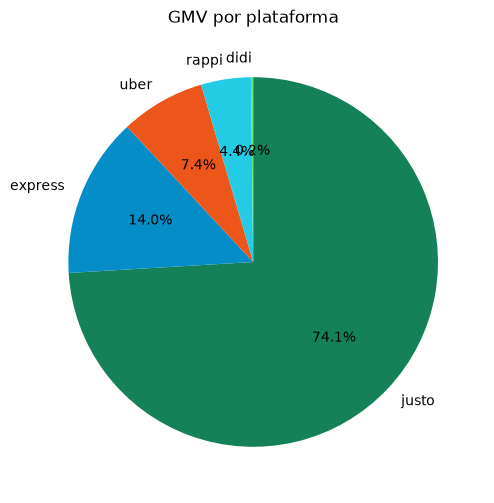

In [11]:
# Paleta "Weekly Pricing" (skill justo-brand-guide) - orden fijo por
# plataforma, no ciclado. No corrido por el validador de contraste de la
# skill dataviz (esto es exploratorio, no un artefacto que se vaya a
# publicar) - si esta grafica se vuelve permanente, correr esa validacion.
COLORES_PLATAFORMA = {
    "justo": "#158158", "express": "#058dc7", "uber": "#ed561b",
    "rappi": "#24cbe5", "didi": "#64e572",
}

mp = marketplace_df.dropna(subset=["GMV_TOTAL"]).sort_values("GMV_TOTAL", ascending=False)
colores = [COLORES_PLATAFORMA.get(p, "#888888") for p in mp["MARKETPLACE"]]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(mp["GMV_TOTAL"], labels=mp["MARKETPLACE"], autopct="%1.1f%%", colors=colores, startangle=90, counterclock=False)
ax.set_title("GMV por plataforma")
plt.show()

### Gráficas: GMV, ticket por unidad, unidades y margen por categoría y por departamento

Reusa `resumen_mecanica` (ya calculado arriba) - no vuelve a consultar
Snowflake. Ayuda a probar la hipótesis de "el ticket alto en Uber/Rappi es
por mezcla de categorías" (si las categorías con ticket alto coinciden con
lo que más se vende en esas plataformas, la explicación es mezcla, no
necesariamente markup).

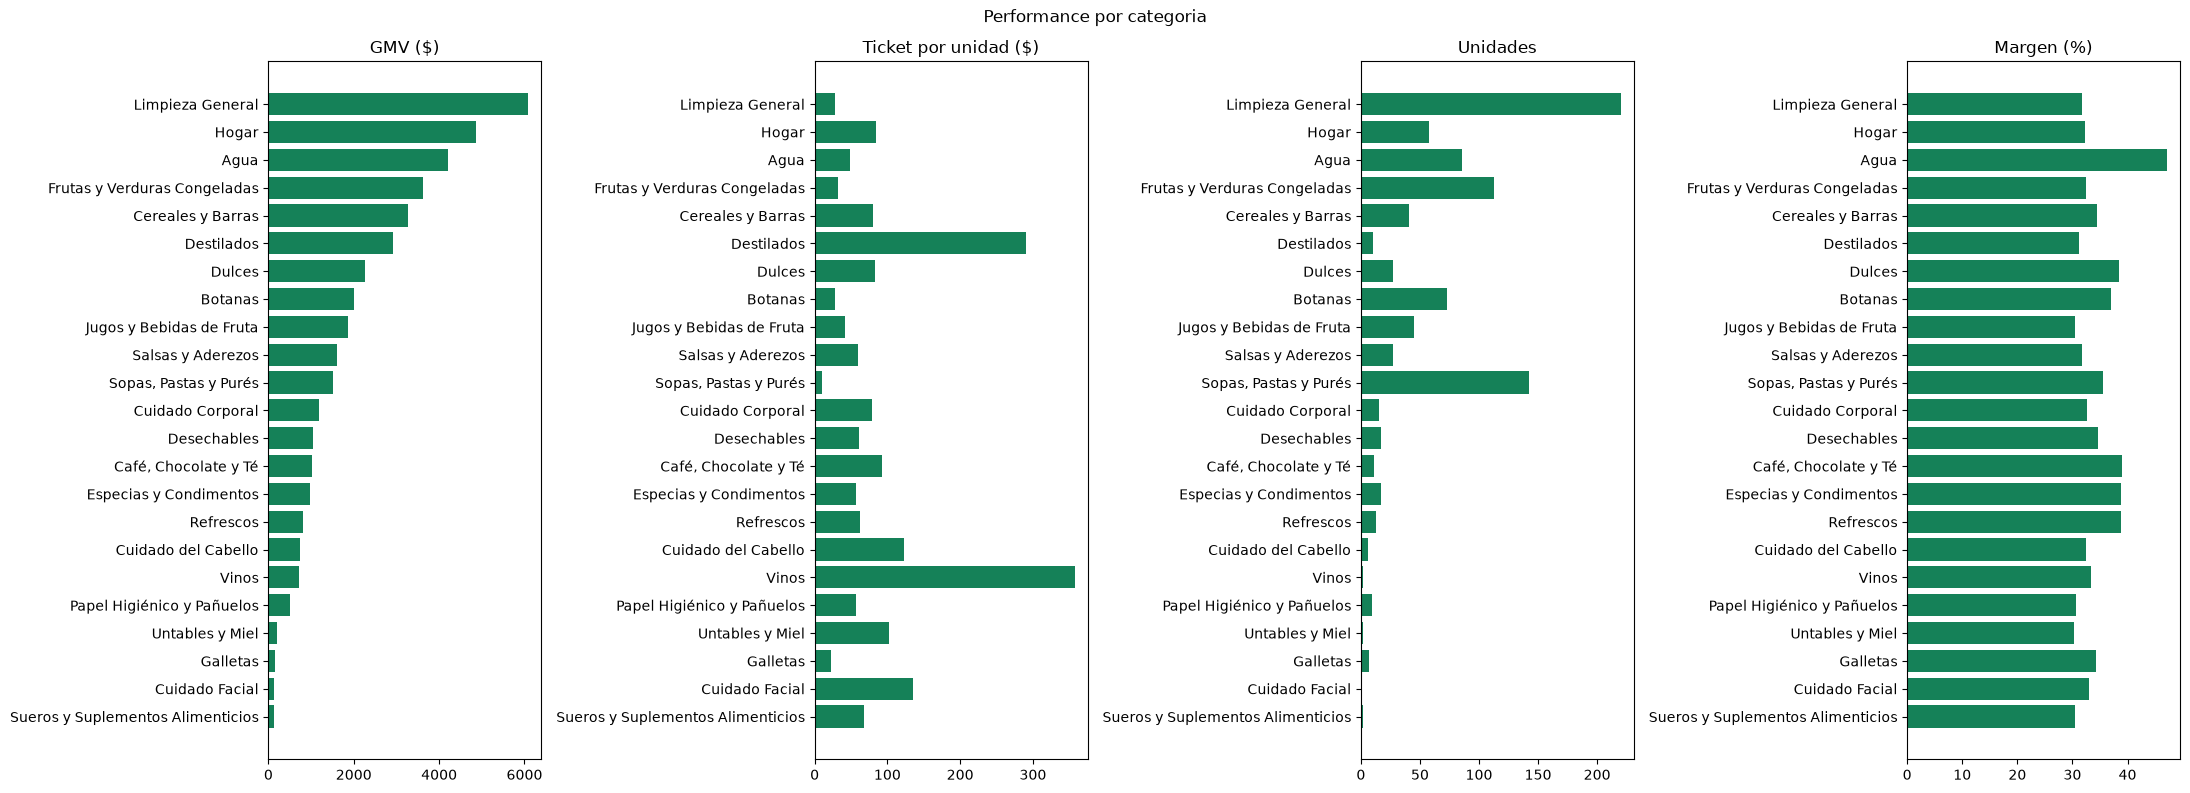

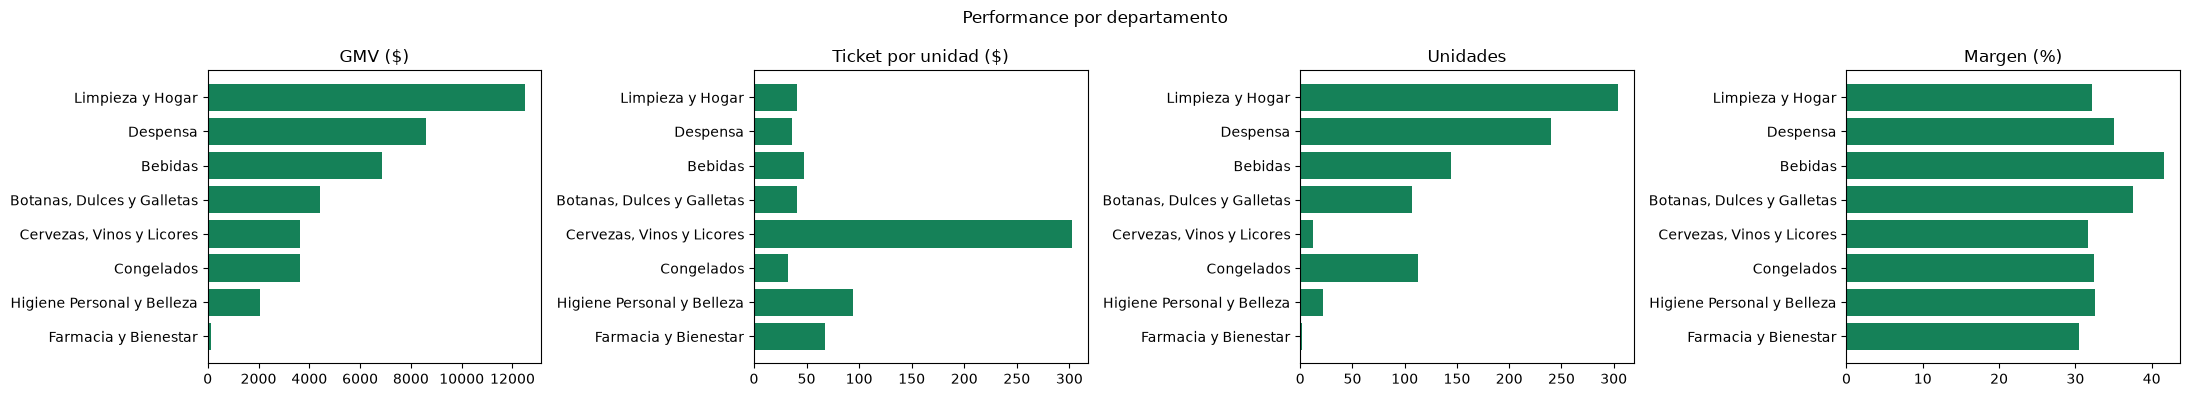

In [12]:
categoria_df = postmortem.resumen_por_categoria(resumen_mecanica)
departamento_df = postmortem.resumen_por_departamento(resumen_mecanica)

METRICAS = [
    ("GMV_TOTAL", "GMV ($)"),
    ("TICKET_POR_UNIDAD", "Ticket por unidad ($)"),
    ("UNIDADES_TOTALES", "Unidades"),
    ("MARGEN_PROMEDIO", "Margen (%)"),
]

for nombre_col, df in [("CATEGORIA", categoria_df), ("DEPARTAMENTO", departamento_df)]:
    df_ordenado = df.sort_values("GMV_TOTAL", ascending=True)
    fig, axes = plt.subplots(1, 4, figsize=(22, max(4, 0.35 * len(df_ordenado))))
    for ax, (campo, titulo) in zip(axes, METRICAS):
        ax.barh(df_ordenado[nombre_col], df_ordenado[campo], color="#158158")
        ax.set_title(titulo)
    fig.suptitle(f"Performance por {nombre_col.lower()}")
    plt.tight_layout()
    plt.show()

### Cruces categoria/departamento x plataforma/tipo de cliente

Para las barras agrupadas del dashboard/reporte (una serie por plataforma o
tipo de cliente, un grupo por categoria/departamento) - responde si el
patron de una categoria se explica por mezcla de plataforma/segmento o es
parejo en todas.

In [13]:
categoria_plataforma_df = postmortem.resumen_por_categoria_y_plataforma(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
departamento_plataforma_df = postmortem.resumen_por_departamento_y_plataforma(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
categoria_segmento_df = postmortem.resumen_por_categoria_y_segmento(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
departamento_segmento_df = postmortem.resumen_por_departamento_y_segmento(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
categoria_plataforma_df

,CATEGORIA,MARKETPLACE,SKUS,UNIDADES_TOTALES,GMV_TOTAL,MARGEN_PROMEDIO,TICKET_POR_UNIDAD
0,Limpieza General,justo,10,171.0,4782.52,31.874380,27.967953
1,Hogar,justo,9,45.0,3804.44,32.455641,84.543111
2,Agua,justo,3,67.0,3506.32,45.932500,52.333134
3,Frutas y Verduras Congeladas,justo,2,104.0,3322.71,32.410000,31.949135
4,Cereales y Barras,justo,3,32.0,2478.94,35.150370,77.466875
...,...,...,...,...,...,...,...
59,Jugos y Bebidas de Fruta,uber,1,1.0,48.48,30.340000,48.480000
60,Salsas y Aderezos,rappi,1,1.0,41.86,34.690000,41.860000
61,Frutas y Verduras Congeladas,uber,1,1.0,32.98,32.630000,32.980000
62,"Sopas, Pastas y Purés",uber,1,2.0,24.12,32.970000,12.060000


### Cruce plataforma x tipo de cliente

Prueba directa de la hipotesis "Sin dato en tipo de cliente es en realidad
marketplace externo": si casi todo el "Sin dato" cae en uber/rappi/didi (no
en justo/express), la hipotesis se confirma.

In [14]:
plataforma_segmento_df = postmortem.resumen_por_plataforma_y_segmento(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
plataforma_segmento_df.pivot(index="MARKETPLACE", columns="SEGMENTO_USUARIO", values="GMV_TOTAL")

SEGMENTO_USUARIO,New,Reactivado,Recurrente,Sin dato
MARKETPLACE,,,,
didi,NaN,NaN,NaN,80.27
express,673.84,2028.26,3112.84,NaN
justo,1897.96,6237.53,22618.08,NaN
rappi,NaN,NaN,NaN,1809.06
uber,NaN,NaN,NaN,3070.29


### Usuarios distintos y ticket promedio por usuario, por segmento

El dato que faltaba para comparar segmentos sin el sesgo de tamaño de
grupo: cuanta GENTE distinta hay en cada uno, no solo cuanto GMV/unidades
sumaron.

In [15]:
usuarios_segmento_df = postmortem.resumen_usuarios_por_segmento(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
usuarios_segmento_df

,SEGMENTO_USUARIO,USUARIOS_DISTINTOS,GMV_TOTAL,TICKET_PROMEDIO_USUARIO
0,Recurrente,299,25730.92,86.056589
1,Reactivado,97,8265.79,85.214330
2,Sin dato,49,4959.62,101.216735
3,New,36,2571.80,71.438889


### Enganche: ticket completo

El ticket por cliente de la campana (~$86) solo cuenta productos
promovidos - esta celda compara el carrito COMPLETO (promovido o no) de
quien compro algo de la campana vs. quien no compro nada, para saber si la
promo arrastro el resto del carrito. Comparacion descriptiva, no causal.

In [ ]:
enganche_orden_df = postmortem.resumen_enganche_por_orden(cur, PROMO_INICIO, PROMO_FIN)
enganche_df = postmortem.resumen_enganche_ticket(cur, PROMO_INICIO, PROMO_FIN)
enganche_segmento_df = postmortem.resumen_enganche_por_segmento(cur, PROMO_INICIO, PROMO_FIN)
print("Por ORDEN (¿el carrito con promo fue mas grande?):")
print(enganche_orden_df.to_string(index=False))
print("\nPor CLIENTE (gasto total en la ventana):")
print(enganche_df.to_string(index=False))
print("\nPor TIPO DE CLIENTE (¿el reactivado que compro campaña, compro mas?):")
print(enganche_segmento_df.to_string(index=False))

### GMV, margen y volumen por mecánica x plataforma x tipo de cliente

Tabla granular a proposito (no grafica) - filtra/ordena para preguntas
puntuales tipo "¿el 5x4 en Uber le fue mejor a Recurrentes o a Nuevos?".

In [16]:
descuento_plataforma_segmento_df = postmortem.resumen_descuento_plataforma_segmento(
    cur, PROMO_INICIO, PROMO_FIN, origen="WKND", adopcion="con_mecanica"
)
descuento_plataforma_segmento_df

,MECANICA_EJECUTADA,MARKETPLACE,SEGMENTO_USUARIO,SKUS,UNIDADES_TOTALES,GMV_TOTAL,MARGEN_PROMEDIO
0,SPON,justo,Recurrente,39,215.0,11399.61,32.287654
1,BNSDP,justo,Recurrente,10,177.0,5370.14,32.605104
2,6x5,justo,Recurrente,5,52.0,3657.12,42.819333
3,SPON,justo,Reactivado,18,83.0,3252.32,32.463750
4,5x4,justo,Recurrente,5,57.0,2191.21,40.312593
5,SPON,uber,Sin dato,10,25.0,1804.79,33.363846
6,SPON,express,Recurrente,15,43.0,1684.56,31.939375
7,BNSDP,justo,Reactivado,5,53.0,1536.32,32.018000
8,SPON,rappi,Sin dato,9,21.0,1365.06,32.964706
9,6x5,justo,Reactivado,2,15.0,1102.94,46.865714


### Reporte HTML del post-mortem (siempre se genera)

Junta todo lo de arriba (`resumen_mecanica`, `top_skus_df`, `resumen_adopcion_df`,
`total_planeado`, `marketplace_df`, `segmento_usuario_df`, `categoria_df`,
`departamento_df`, `plataforma_segmento_df`, `usuarios_segmento_df`,
`descuento_plataforma_segmento_df`) en un solo reporte HTML autonomo (mismo
estilo, mismos KPIs/graficas/tablas que el dashboard), guardado en
`data/output/`. Correr esta celda es el ultimo paso estandar de cualquier
post-mortem, no un entregable manual aparte.

In [ ]:
ruta_reporte = postmortem.generar_reporte_html(
    resumen_mecanica, top_skus_df, PROMO_INICIO, PROMO_FIN,
    resumen_df=resumen_adopcion_df, total_planeado=total_planeado,
    marketplace_df=marketplace_df, segmento_usuario_df=segmento_usuario_df,
    categoria_df=categoria_df, departamento_df=departamento_df,
    categoria_plataforma_df=categoria_plataforma_df, departamento_plataforma_df=departamento_plataforma_df,
    categoria_segmento_df=categoria_segmento_df, departamento_segmento_df=departamento_segmento_df,
    plataforma_segmento_df=plataforma_segmento_df, usuarios_segmento_df=usuarios_segmento_df,
    descuento_plataforma_segmento_df=descuento_plataforma_segmento_df,
    enganche_df=enganche_df, enganche_orden_df=enganche_orden_df,
    enganche_segmento_df=enganche_segmento_df,
    ruta_salida=f"../data/output/postmortem_{PROMO_INICIO.strftime('%b%d').lower()}_{PROMO_FIN.strftime('%b%d').lower()}_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.html",
)
print(f"Reporte generado en: {ruta_reporte}")